#### Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
sales_df = pd.read_csv("C:/Users/Senthil/Downloads/advertising_and_sales_clean.csv")

In [4]:
sales_df.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


Creating features

In [5]:
X = sales_df["radio"].values
y = sales_df["sales"].values

In [8]:
X = X.reshape(-1, 1)

print(X.shape)
print(y.shape)

(4546, 1)
(4546,)


Building a linear regression model

In [9]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)

y_pred = reg.predict(X)

Visualizing a linear regression model

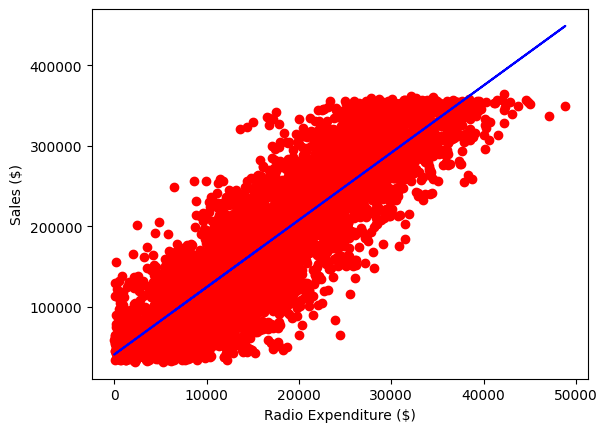

In [12]:
plt.scatter(X, y, color="red")
plt.plot(X, y_pred, color="blue")

plt.xlabel("Radio Expenditure ($)")
plt.ylabel("Sales ($)")

plt.show()

#### Multiple Linear Regression

Fit and predict for regression

In [20]:
X = sales_df.drop(columns=["sales", "influencer"], axis=1).values
y = sales_df["sales"].values

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [24]:
print("Predictions: {} Actual Values: {}".format(y_pred[:2], y_test[:2]))

Predictions: [53176.66154234 70996.19873235] Actual Values: [55261.28 67574.9 ]


Regression performance

In [25]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
r_squared = reg.score(X_test, y_test)

print("RMSE: {}".format(rmse))
print("R squared: {}".format(r_squared))

RMSE: 2944.4331996001015
R squared: 0.9990152104759368


Cross Validation for r squared

In [30]:
from sklearn.model_selection import KFold, cross_val_score

reg = LinearRegression()

kf = KFold(n_splits=6, shuffle=True, random_state=42)
cv_results = cross_val_score(estimator=reg, X=X, y=y, cv=kf)

In [31]:
cv_results

array([0.99900913, 0.99898729, 0.99897163, 0.99898887, 0.99893043,
       0.99905966])

In [33]:
print(cv_results.mean())
print(cv_results.std())
print(np.quantile(cv_results, [0.025, 0.975]))

0.9989911695584723
3.895599514495595e-05
[0.99893558 0.99905335]


Regularised Regression : Ridge

In [34]:
from sklearn.linear_model import Ridge

alphas = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    scores.append(ridge.score(X_test, y_test))

In [35]:
scores

[0.9990152104759369,
 0.9990152104759373,
 0.9990152104759419,
 0.999015210475987,
 0.9990152104764387,
 0.9990152104809561]

Regularised Regression : Lasso

In [36]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.3)

lasso.fit(X_train, y_train)
lasso_coefs = lasso.coef_

Lasso for Feature Selection

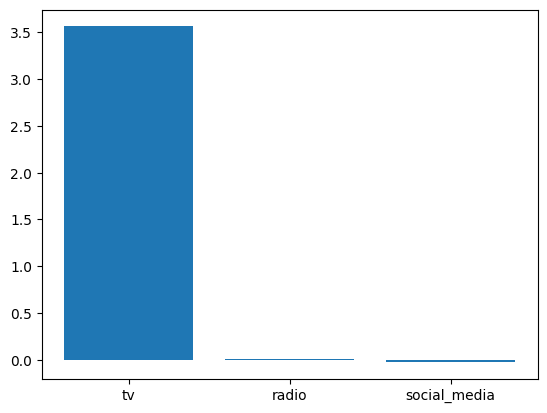

In [39]:
names = sales_df.drop(columns=["sales", "influencer"]).columns
plt.bar(names, lasso_coefs)
plt.show()